----
# Word2Vec
-----

## Notebook Summary

In this notebook, I’ll explore **Word2Vec**, a method used to transform email text into word embeddings. Word embeddings are a numerical representation of words, where words with similar meanings are represented by vectors that are close to each other in the vector space.

This notebook follows a similar layout to the TF-IDF notebook:

1. **Data Loading:** Load the cleaned data from the data folder.

2. **Preparing Text:** Preprocess the text for tokenisation, handling stopwords, and using SpaCy to remove irrelevant words.

3. **Transform Text:** Apply Word2Vec to convert words to embeddings and explore semantic relationships between them.

4. **Topic Modelling with LDA:** Group the data into topics and analyse groupings.


## Set Up
---

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

import re
import string

import spacy
import gensim
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

## Data Loading
----

In [77]:
emails_df = pd.read_csv('../../data/cleaned_emails.csv', index_col= 0)

In [78]:
# working with subset of data first to assess results
email_subset_df = emails_df[:20_000].copy()

## Preparing Text
-----

### Combine subject and body

In [79]:
# Combining subject and body to better understand context of emails
email_subset_df['all_text'] = email_subset_df['cleaned_subject'] + ' ' + email_subset_df['cleaned_body']

### Tokenise text using simple_preprocess

In [80]:
nltk.download('stopwords')
eng_stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/simybasra/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [81]:
# since punc was removed in cleaning, I need to do the same for stop words
# using regexp to remove all characters which are not words or whitespaces (punctuation)
processed_stop_words = [re.sub(r'[^\w\s]', '', word) for word in eng_stop_words]

In [82]:
# custom list of stop words, all are in lower case since in tokeniser I will force case to be lower
greetings = ['hello', 'hi', 'dear', 'regards', 'thanks', 'thank', 'sincerely', 'best', 'regard', 'regarding', 'activity']
email_jargon = ['re', 'fw', 'cc','forwarded','forward','original message','original', 'bcc','x', 'subject', 'message', 'email', 'mail','intend','recipient']
std_phrases= ['also', 'please', 'let', 'know', 'kindly', 'attached', 'find', 'below', 'attach','pm', 'am','like','see','time','us', 'right', 'said', 'information', 'team', 'office', 'company', 'order', 'change', 'provide', 'give', 'scheduled', 'made', 'play']
std_words = ['go', 'get', 'take', 'come', 'think', 'make', 'enron', 'going','look','may','image', 'list', 'would', 'could' ,'fax', 'name', 'one','want','call', 'use','new', 'need', 'meet', 'work','receives', 'receiving','back', 'great', 'received', 'first', 'last', 'much', 'since', 'many']
irrelevant_words = [ 'phone', 'long', 'term', 'good', 'web', 'site', 'feel', 'free', 'question', 'questions', 'contact' ,'concern', 'put','per', 'dec','together', 'im','sure','night', 'soon', 'possible','third','parties','hope', 'well', 'even', 'though','request', 'still', 'following', 'active','help', 'available', 'game', 'way', 'position', 'two', 'updated', 'number', 'people', 'group', 'system', 'process', 'start', 'send', 'receive', 'day', 'date']
additional_stop_words = [
    'meeting', 'gas', 'business', 'market', 'report', 'power', 'expected', 'comment', 'comments', 'agent', 'communication',
    'review', 'management', 'plan', 'service', 'issues', 'data', 'numbered', 'pt', 'today', 'based', 'id','need', 'user',
    'deal', 'offer', 'visit', 'houston', 'address', 'online', 'access', 'able', 'sent', 'working', 'yards', 
    'note', 'set', 'changes', 'due', 'support', 'keep', 'credit', 'london', 'discuss', 'current', 'intended', 'tofrom', 'place', 'however', 
    'services', 'reports', 'must', 'check', 'points', 'employees', 'companies', 'operation', 'pointed', 'point', 'points','pointing',
    'cost', 'project', 'value', 'hour', 'area', 'might', 'morning', 'result', 'line', 'big', 'guy', 'guys', 'currently', 
    'opportunity', 'end', 'news', 'city', 'option', 'share', 'including','part', 'parts', 'approval', 'used', 'looking',
    'point', 'file', 'prices', 'say', 'update', 'copy', 'detail', 'rate', 'thing', 'fantasy', 'done',
    'problem', 'transaction', 'special', 'complete','completed', 'completing','account', 'click', 'link', 'schedule', 'comment', 'member', 'future', 'th', 'thought', 'additional', 'around', 'another', 'detail'
]
additional_stop_words.extend([
    'just','return','returns', 'returned','returning', 'really', 'actually', 'kind', 'often', 'simply', 'totally', 'definitely', 'got', 'numbers', 'numbering', 'already',
    'investment', 'project', 'financial', 'market', 'partner', 'value', 'costs', 'consult','person', 'player',
    'clients', 'growth', 'useful', 'important', 'available', 'ensure', 'confirm', 'consider', 'got', 'item', 'times', 'high', 'highs', 'low', 'lows',
    'long-term', 'year', 'week', 'month', 'day', 'confirm', 'understand', 'appreciate', 'response',
    'reply', 'feedback', 'software', 'platform', 'code', 'error', 'system', 'debug', 'version', 
    'host', 'data center', 'thank', 'please', 'attached', 'forwarded', 'message', 'kindly', 'subject',
    'forward', 'the', 'a', 'an', 'of', 'in', 'to', 'on', 'at', 'from', 'for', 'with', 'by', 'about',
    'no', 'not', 'never', 'none', 'nothing', 'without', 'option', 'better', 'state', 'company', 'customer',
    'operation', 'details', 'agreement', 'contract', 'deal', 'million', 'continue', 'view', 'texas', 'within', 'unit', 'level',
    'believe', 'deals', 'issue', 'issues', 'include', 'home', 'program', 'total', 'comment', 'volume'
])
custom_stop_words = greetings + email_jargon + std_phrases + std_words + irrelevant_words + additional_stop_words

# adding all custom stop words to existing list 
processed_stop_words.extend(custom_stop_words)

### Removing Employee Names, Dates and Organisations

In [83]:
# load the pre-trained spaCy model for NER
nlp = spacy.load('en_core_web_sm')

def remove_names(text):
    # ensuring all text is of type string
    text = str(text)
    # using model to process email text (subject + body)
    doc = nlp(text)
    # need to reverse order in which entities are removed to avoid disrupting order of text
    #  important as otherwise model will not recognise other entities to be removed
    for e in reversed(doc.ents):
        # to remove words where entity is PERSON, ORG or DATE
        if e.label_ in ("PERSON", "ORG", "DATE",): 
            # remove the entity by slicing the text: 
            #   keep the part before the entity, skip the entity itself and keep the part after it
            text = text[:e.start_char] + text[e.start_char + len(e.text):]

    return text


In [84]:
email_subset_df['all_text'] = email_subset_df['all_text'].apply(remove_names)

## Tokenise Text
-----

In [85]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/simybasra/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [86]:
lemmatizer = WordNetLemmatizer()

In [87]:
# # loop througheach email in the dataset
# for email in email_subset_df['all_text']:
#     # tokenise the email text using simple_preprocess
#     tokens = simple_preprocess(email)
#     # filter out stopwords
#     # filtered_tokens = [token for token in tokens if token not in processed_stop_words]
#     # Add remaining tokens to tokened_emails
#         # Step 3: Lemmatize the filtered tokens
#     lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
#     # Add lemmatized tokens to your tokened_emails list
#     tokened_emails.append(lemmatized_tokens)

In [88]:
custom_stop_words = ['niamh', 'ew']

In [126]:
def my_tokenizer(email):
    """
    A custom tokeniser to use in TF-IDF Vecotoriser.
    Preprocesses input text and produces tokens.
    """
    email = email.lower()
    
    # to remove numbers
    email = re.sub(r'\d+','',email)
    # splitting each sentence by space into words
    listofwords = email.split(' ')
    listoflemm_words = []
    
    for word in listofwords:  
        # filtering out stopwords and any tokens that are just empty strings
        if (word != ''):
            # using 'lemmatize to cut words to their base 
            lemm_word = lemmatizer.lemmatize(word)
            listoflemm_words.append(lemm_word)

    return listoflemm_words

In [127]:
tokened_emails = []

for email in email_subset_df['all_text']:
    # tokenise the email text using simple_preprocess
    tokens = my_tokenizer(email)
    # if tokens:
        # Add lemmatized tokens to your tokened_emails list
    tokened_emails.append(tokens)


In [128]:
tokened_emails

[['re',
  'traveling',
  'to',
  'have',
  'a',
  'business',
  'meeting',
  'take',
  'the',
  'fun',
  'out',
  'of',
  'the',
  'trip',
  'especially',
  'if',
  'you',
  'have',
  'to',
  'prepare',
  'a',
  'presentation',
  'i',
  'would',
  'suggest',
  'holding',
  'the',
  'business',
  'plan',
  'meeting',
  'here',
  'then',
  'take',
  'a',
  'trip',
  'without',
  'any',
  'formal',
  'business',
  'meeting',
  'i',
  'would',
  'even',
  'try',
  'and',
  'get',
  'some',
  'honest',
  'opinion',
  'on',
  'whether',
  'a',
  'trip',
  'is',
  'even',
  'desired',
  'or',
  'necessary',
  'a',
  'far',
  'a',
  'the',
  'business',
  'meeting',
  'i',
  'think',
  'it',
  'would',
  'be',
  'more',
  'productive',
  'to',
  'try',
  'and',
  'stimulate',
  'discussion',
  'across',
  'the',
  'different',
  'group',
  'about',
  'what',
  'is',
  'working',
  'and',
  'what',
  'is',
  'not',
  'too',
  'often',
  'the',
  'presenter',
  'speaks',
  'and',
  'the',
  'oth

In [129]:
# sanity check to see all emails have list of tokens
len(tokened_emails)

20000

## Vecotrise Text using Word2Vec
----

In [155]:
# Train the Word2Vec model
lda_model = Word2Vec(
                sentences=tokened_emails,
                vector_size=200,  # size of embeddings, higher values capture more semantics
                window=5,        # setting to 5 to capture more context 
                min_count=5,      # ensure rare words are included 
                workers=4,          
                sg = 1,            # choosing to use Skip-Gram
                seed = 11, 
                epochs = 15
            )

## Most Frequent Words in Emails
----

In [147]:
from wordcloud import WordCloud

In [55]:
word_freq_dict = {}

In [38]:
from collections import Counter

# Tokenize the emails and flatten the list of tokens (you already have tokened_emails)
all_tokens = [token for tokens in tokened_emails for token in tokens]

# Count word frequencies
word_freq = Counter(all_tokens)

for word, freq in word_freq.most_common(20):
    word_freq_dict[word] = freq

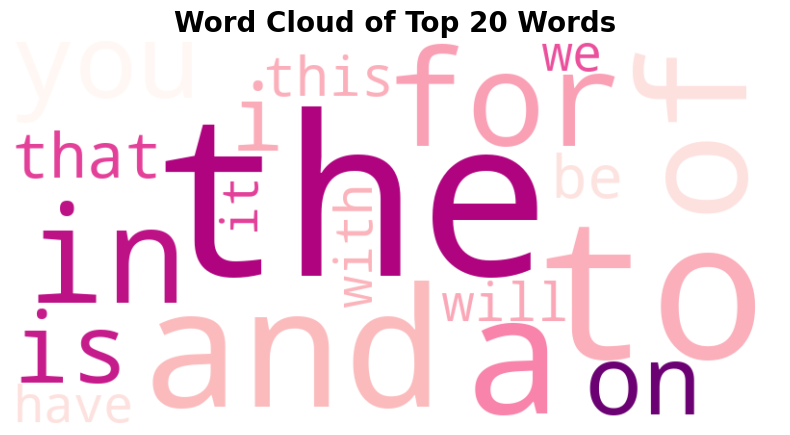

In [39]:
# Create the word cloud
wordcloud = WordCloud(
                width=800,
                height=400,
                background_color='white',
                colormap='RdPu'
            ).generate_from_frequencies(word_freq_dict)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') 
plt.title('Word Cloud of Top 20 Words', fontsize=20, fontweight = 'bold')
plt.show()

----
**Comment:**

**FIRST PASS**

`{'information': 6415,
 'meeting': 5860,
 'gas': 5010,
 'business': 4363,
 'game': 4319,
 'market': 3890,
 'team': 3854,
 'report': 3780,
 'active': 3577,
 'power': 3507,
 'help': 3431,
 'following': 3357,
 'review': 3343,
 'price': 3283,
 'risk': 3261,
 'trading': 3252,
 'updated': 3252,
 'company': 3181,
 'available': 3112,
 'still': 3075}`

Most common words are : information, meeting, gas and business. 

Reflect common words in a corporate setting, 'information' and 'meeting' suggest most emails are based around information sharing and updates. 'gas' and 'power' also makes sense as ENRON was an energy company. 

There is still room for improvement here, for example the word 'still' appears in the top 20. This isn't really a word that is meaningful and is rather common in conversations and doesn't add to much to the analysis so will be adding this to the stop word list in addition to following, active, team, help, available. 

**FINAL PASS**

After repeating the above process, I think I am at a point where I can continue to get a deeper understanding to the embeddings, it would make sense to see if Word2Vec captured the semantic relationships between the embeddings. In other words, terms like market and trading should have similar embeddings.


## Assess Embedding Relations
-----

In [156]:
def semantic_rels(word):
    # get the embedding for a word
    embedding = lda_model.wv[word]  
    # find most 5 similar words
    similar_words = lda_model.wv.most_similar(word, topn=5)

    return(f'Words similar to {word}:', similar_words)

In [157]:
semantic_rels('houston') 

('Words similar to houston:',
 [('ew', 0.5272419452667236),
  ('bwbwtneprc', 0.5072680115699768),
  ('bwlloopnwaccprc', 0.5044682025909424),
  ('bwlloopnwprc', 0.4981350302696228),
  ('bwbwtseprc', 0.49710190296173096)])

In [158]:
semantic_rels('information') 

('Words similar to information:',
 [('infor', 0.5781628489494324),
  ('informa', 0.545768141746521),
  ('eessvcs', 0.5404103398323059),
  ('informaiton', 0.5330884456634521),
  ('cdy', 0.5302848219871521)])

----
**Comment:**



## Using pretrained model (Google's KeyedVectors)
---

----
**Comment:**



## Summary
----